<>:350: SyntaxWarning: invalid escape sequence '\s'
<>:350: SyntaxWarning: invalid escape sequence '\s'
/var/folders/0c/82_znf0d1233xpn7y3qx59c40000gn/T/ipykernel_1118/1759109416.py:350: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Noise Standard Deviation $\sigma^2$")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
11
Testing sigma = 1e-06...
Testing sigma = 1e-05...
Testing sigma = 0.0001...
Testing sigma = 0.001...
Testing sigma = 0.01...
Testing sigma = 0.1...


Text(0.5, 1.0, 'Experiment 1: Relative Error')

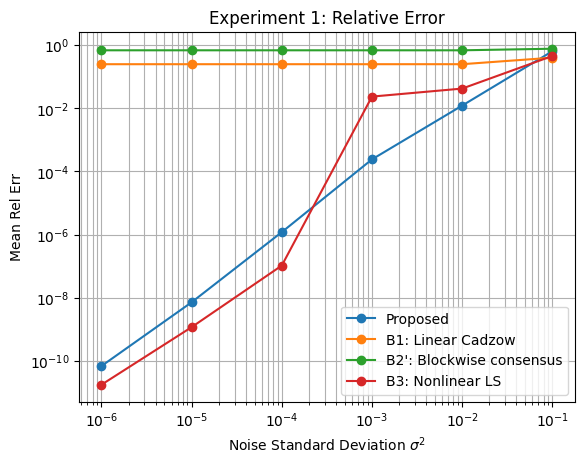

In [169]:
### Experiment 1
%load_ext autoreload
%autoreload 2
import numpy as np
import time
from scipy.linalg import hankel, svd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

#########################################
#Hankel
def hankel_matrix(y, L):
    y = np.asarray(y)
    T = len(y)
    return np.column_stack([y[i:T-L+i+1] for i in range(L)])

def hankel_proj(X):

    m, n = X.shape
    v = np.zeros(m + n - 1)
    counts = np.zeros(m + n - 1)
    for i in range(m):
        for j in range(n):
            v[i + j] += X[i, j]
            counts[i + j] += 1
    return v / counts

def hankel_proj_mat(X):
    m, n = X.shape
    L = m + n - 1
    v = np.zeros(L)
    counts = np.zeros(L)
    
    # Step 1: Average the anti-diagonals (Signal Recovery)
    for i in range(m):
        for j in range(n):
            v[i + j] += X[i, j]
            counts[i + j] += 1
    v_avg = v / counts
    
    # Step 2: Reconstruct the Hankel matrix
    # The first column is v_avg[0:m], the last row is v_avg[m-1:L]
    return hankel(v_avg[:m], v_avg[m-1:])

def proj_rank_r(M, r):
    U, S, Vh = svd(M, full_matrices=False)
    M_hat = U[:, :r] @ np.diag(S[:r]) @ Vh[:r, :]
    return M_hat

def hankel_to_signal(H):
    H = np.asarray(H)
    m, n = H.shape
    L = m + n - 1
    y = np.zeros(L, dtype=H.dtype)
    counts = np.zeros(L)

    for i in range(m):
        for j in range(n):
            y[i + j] += H[i, j]
            counts[i + j] += 1
            
    return y / counts

def lifted_hankel_matrix(y, u, L, feature_funcs):
    blocks = []
    # Block 0: Linear y
    blocks.append(hankel(y[:L], y[L-1:]))
    # Blocks 1 to q: Nonlinear features
    for func in feature_funcs:
        feat_y = func(y)
        blocks.append(hankel(feat_y[:L], feat_y[L-1:]))
    # Block q+1: Input u
    blocks.append(hankel(u[:L], u[L-1:]))
    return np.vstack(blocks)

###############################################
# Methods
def linearized_consensus_solve(y_current, z_targets, feature_funcs, jac_funcs, rho=1e-4):
    N = len(y_current)
    # A_0 = Identity (for y), b_0 = target_y - y
    A_blocks = [np.eye(N)]
    b_blocks = [z_targets[0] - y_current]

    for f, jac, z in zip(feature_funcs, jac_funcs, z_targets[1:]):
        A_blocks.append(jac(y_current))
        b_blocks.append(z - f(y_current))

    A = np.vstack(A_blocks)
    b = np.concatenate(b_blocks)
    # Solve (A'A + rho*I) dy = A'b
    dy = np.linalg.solve(A.T @ A + rho * np.eye(N), A.T @ b)
    return dy

def linearized_consensus_slra(y_noisy, u, L, r, feature_funcs, jac_funcs, 
                               alpha, max_iter, rho=1e-2, tol=1e-6):
    y = y_noisy.copy()
    N = len(y)
    q = len(feature_funcs)

    M = lifted_hankel_matrix(y_noisy, u, L, feature_funcs)
    U, S, Vh = svd(M, full_matrices=False)
    
    for k in range(max_iter):
        y_prev = y.copy()
        
        # 1. Lift and Rank Projection
        #M = lifted_hankel_matrix(y, u, L, feature_funcs)
        #U, S, Vh = svd(M, full_matrices=False)
        M_hat = U[:, :r] @ np.diag(S[:r]) @ Vh[:r, :]
        
        # 2. Extract targets z (only for y and nonlinear features, ignore u block)
        z_targets = []
        for j in range(q + 1):
            block = M_hat[j*L : (j+1)*L, :]
            z_targets.append(hankel_proj(block))
        
        # 3. Consensus Step
        delta_y = linearized_consensus_solve(y, z_targets, feature_funcs, jac_funcs, rho)
        
        # 4. Relaxed Update (Mann Iteration)
        y = y + alpha * delta_y
        
        # Convergence check
        M = lifted_hankel_matrix(y, u, L, feature_funcs)
        U, S, Vh = svd(M, full_matrices=False)
        #if S[-1] <= tol:
        if np.linalg.norm(y - y_prev) <= tol or S[-1]<=tol :
            return y, k + 1
            
    return y, k+1


def b1_linear_cadzow(u, y0, L, maxiter, r_lin=None, tol=1e-6):
    """
    B1: Cadzow on H(y) only.
    Returns (y_hat, nit).
    """
    H = hankel_matrix(y0, L)
    U,sv,Vh = np.linalg.svd(H,full_matrices=False)
    if r_lin is None:
        r_lin = max(1, L - 1)
    for it in range(maxiter):    
        
        y = y0.copy()
    
        #H = hankel_matrix(y, L)
        #Hr = proj_rank_r(H, r_lin)
        #Hh = hankel_proj_mat(Hr)
        Hh = U[:, :r_lin] @ np.diag(sv[:r_lin]) @ Vh[:r_lin, :]
        y_new = hankel_to_signal(Hh)
        H = hankel_matrix(y_new, L)
        U,sv,Vh = np.linalg.svd(H, full_matrices=False)
        if np.linalg.norm(y_new - y) <= tol or sv[-1]<=tol:
            return y_new, it + 1
        y = y_new

    return y, it+1


def b2_consensus(y_noisy, u, L, r, feature_funcs, maxiter, alpha=0.5, tol=1e-6,
                 w=(0.4, 0.3, 0.3)):
    y = np.asarray(y_noisy).copy()
    N = len(y)
    w = np.asarray(w) / np.sum(w)
    M = lifted_hankel_matrix(y, u, L, feature_funcs)
    U,sv,Vh = np.linalg.svd(M,full_matrices=False)
    for it in range(maxiter):
        #M = lifted_hankel_matrix(y, u, L, feature_funcs)
        #Y = proj_rank_r(M, r)
        Y = U[:, :r] @ np.diag(sv[:r]) @ Vh[:r, :]

        # 1. Structural Projection (Hankelization)
        # Block 0: y(t), Block 1: cross-term f1, Block 2: tanh f2
        y_hat = hankel_to_signal(hankel_proj_mat(Y[0*L:1*L, :]))
        c_hat = hankel_to_signal(hankel_proj_mat(Y[1*L:2*L, :]))
        h_hat = hankel_to_signal(hankel_proj_mat(Y[2*L:3*L, :]))

        # 2. Estimate 0: Direct y(t)
        y_est0 = y_hat 

        # 3. Estimate 1: From -3 * y(t-1)^2 * y(t-2)
        # c_hat[t] corresponds to y(t-1). We need to shift it to get y(t).
        y_prev = y
        y_prev_prev = np.concatenate([[0], y[:-1]])
        denom = -3 * (y_prev * y_prev_prev)
        
        y_inv_c = (c_hat * denom) / (denom**2 + 1e-4) # Regularized division
        
        y_est1 = np.zeros(N)
        y_est1[:-1] = y_inv_c[1:] # Shift left to align y(t-1) -> y(t)
        y_est1[-1] = y_inv_c[-1]

        # 4. Estimate 2: From tanh(y(t))
        # h_hat[t] is already tanh(y[t]). NO SHIFT NEEDED.
        h_clipped = np.clip(h_hat, -1.0 + 1e-5, 1.0 - 1e-5)
        y_est2 = np.arctanh(h_clipped)

        # 5. Combination
        y_new = w[0]*y_est0 + w[1]*y_est1 + w[2]*y_est2
        
        y_next = (1 - alpha) * y + alpha * y_new
        y_next = np.clip(y_next, -5, 5) # Safety clip

        M = lifted_hankel_matrix(y_next, u, L, feature_funcs)
        U,sv,Vh = np.linalg.svd(M, full_matrices=False)
        if np.linalg.norm(y_next - y) <= tol or  sv[-1]<=tol:
            return y_next, it + 1
        y = y_next

    return y, it + 1

def b3_nonlinear_ls(u, y_init, L, r, feature_funcs, maxfev):
    """
    B3: minimize ||M(u,y) - P_r(M(u,y))||_F^2 with LM.
    """
    y_init = np.asarray(y_init, dtype=float).ravel()

    #def residual(y_vec):
    #    M = lifted_hankel_matrix(y_vec, u, L, feature_funcs)
    #    Mr = proj_rank_r(M, r)
    #    return (M - Mr).ravel()
    def residual(y_vec):
       M = lifted_hankel_matrix(y_vec, u, L, feature_funcs)
       _, s, _ = svd(M, full_matrices=False)
       return s[r:] # Minimize the tail of the spectrum

    res = least_squares(residual, y_init, jac = '3-point', method="trf", max_nfev=maxfev)
    return res.x, res.nfev
#######################################
# --- Trajectory Definition ---
def f1(y): 
    f = np.zeros_like(y)
    for t in range(2, len(y)):
        #f[t] = -3 * (y[t-1]**2) * y[t-2]
        f[t] = (y[t-1]**2) * y[t-2]
    return f

def j1(y):
    N = len(y)
    L1 = np.zeros((N, N))
    for t in range(2, N):
        #L1[t, t-1] = -6 * y[t-1] * y[t-2]
        #L1[t, t-2] = -3 * y[t-1]**2
        L1[t, t-1] =  y[t-1] * y[t-2]
        L1[t, t-2] =  y[t-1]**2
    return L1

def f2(y): 
    f = np.zeros_like(y)
    # y[t-1] for t=1..N-1
    f[1:] = np.tanh(y[:-1])
    return f
def j2(y): return np.diag(1 - np.tanh(y)**2)

def simulate_trajectory(N, gamma=1.0, seed=42):
    np.random.seed(seed)
    u = np.random.normal(0, 0.5, N) # Reduced scale for stability
    y = np.zeros(N)
    y[0] = -0.1 # Reduced initial condition to avoid blow-up
    for t in range(2, N):
        y[t] = 0.1*u[t-1] - 3*(y[t-1]**2)*y[t-2] + gamma*np.tanh(y[t-1])
    return u, y

def est_rank(u, y, L, feature_funcs):
    M = lifted_hankel_matrix(y, u, L, feature_funcs)
    r = np.linalg.matrix_rank(M, 1e-10)
    return r

#Error
def rel_err(y, y_true):
    abserr = np.linalg.norm(y - y_true)**2
    return abserr/np.linalg.norm(y_true)**2

def run_study(y_true, u, L, r, feature_funcs, noise_levels, num_trials):
    methods = ['Proposed', 'Lin. Cadzow', 'Block Cadzow', 'Nonlinear_LS']
    n_methods = len(methods)
    n_noise = len(noise_levels)
    
    # Storage: (Noise_Level, Trial, Method)
    # This 3D matrix holds the Relative Error for every single run
    error_results = np.zeros((num_trials,n_noise, n_methods))
    time_results = np.zeros((num_trials,n_noise, n_methods))
    iters_results = np.zeros((num_trials,n_noise, n_methods))

    for i, sigma in enumerate(noise_levels):
        print(f"Testing sigma = {sigma}...")
        
        for t in range(num_trials):
            #print(t)
            y_noisy = y_true + np.random.normal(0, sigma, y_true.shape)
            
            for j, name in enumerate(methods):
                
                
                # --- Method Execution ---
                if name == 'Proposed':
                    t0 = time.perf_counter()
                    y_denoised, iters = linearized_consensus_slra(y_noisy, u, L, r, [f1, f2], [j1, j2], alpha=0.5, max_iter=10000, rho=1e-2, tol=1e-06) 
                    t1 = time.perf_counter() - t0
                    time_results[t, i, 0] = t1
                    error_results[t, i, 0] = rel_err(y_denoised, y_true)
                    iters_results[t, i, 0] = iters
                elif name == 'Lin. Cadzow':
                    t0 = time.perf_counter()
                    y_lincad, iterslincad = b1_linear_cadzow(u, y_noisy, L, maxiter=10000, r_lin=None, tol=1e-6)
                    t2 = time.perf_counter() - t0
                    time_results[t, i, 1] = t2
                    error_results[t, i, 1] = rel_err(y_lincad, y_true)
                    iters_results[t, i, 1] = iterslincad
                elif name == 'Block Cadzow':
                    t0 = time.perf_counter()
                    y_bcad, itersbcad = b2_consensus(y_noisy, u, L, r, [f1, f2], maxiter=10000, alpha=0.5, tol=1e-6,w=(0.6, 0.2, 0.2))
                    t3 = time.perf_counter()-t0
                    time_results[t, i, 2] = t3
                    error_results[t, i, 2] = rel_err(y_bcad, y_true)
                    iters_results[t, i, 2] = itersbcad
                elif name == 'Nonlinear_LS':
                    t0 = time.perf_counter()
                    ynls, nfev = b3_nonlinear_ls(u, y_noisy, L, r, [f1, f2], maxfev=10000)
                    t4 = time.perf_counter()-t0
                    time_results[t, i, 3] = t4
                    error_results[t, i, 3] = rel_err(ynls, y_true)
                    iters_results[t, i, 3] = nfev
                
                # ------------------------
    return error_results, time_results, iters_results

N=90
L = 3
gamma=1.0
ntrials = 50
noise_lev = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
u_true, y_true = simulate_trajectory(N, gamma, seed=42)
r = est_rank(u_true, y_true, L, [f1, f2])
print(r)

errs, times, iters = run_study(y_true, u_true, L, r, [f1, f2], noise_lev, ntrials)

#print(np.mean(errs[:,:,0],axis=0))
errP = np.mean(errs[:,:,0],axis=0)
errlincad = np.mean(errs[:,:,1],axis=0)
errbcad = np.mean(errs[:,:,2],axis=0)
errnls = np.mean(errs[:,:,3],axis=0)

plt.figure()
plt.loglog(noise_lev, errP, marker="o", label="Proposed")
plt.loglog(noise_lev, errlincad, marker="o", label="B1: Linear Cadzow")
plt.loglog(noise_lev, errbcad, marker="o", label="B2': Blockwise consensus")
plt.loglog(noise_lev, errnls, marker="o", label="B3: Nonlinear LS")
plt.xlabel("Noise Standard Deviation $\sigma^2$")
plt.ylabel("Mean Rel Err")
plt.grid(True, which="both")
plt.legend()
plt.title("Experiment 1: Relative Error")

77.0
Method | Avg Time (s) | Avg Iterations/Nfev
Proposed     | 0.2187 | 628.0
Lin. Cadzow  | 0.7500 | 10000.0
Block Cadzow | 0.0058 | 13.0
Nonlinear_LS | 1.4408 | 137.5


<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/var/folders/0c/82_znf0d1233xpn7y3qx59c40000gn/T/ipykernel_1118/3195361882.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.annotate(f"$\sigma$={txt:.0e}", (avg_times[i, 0], avg_errs[i, 0]),


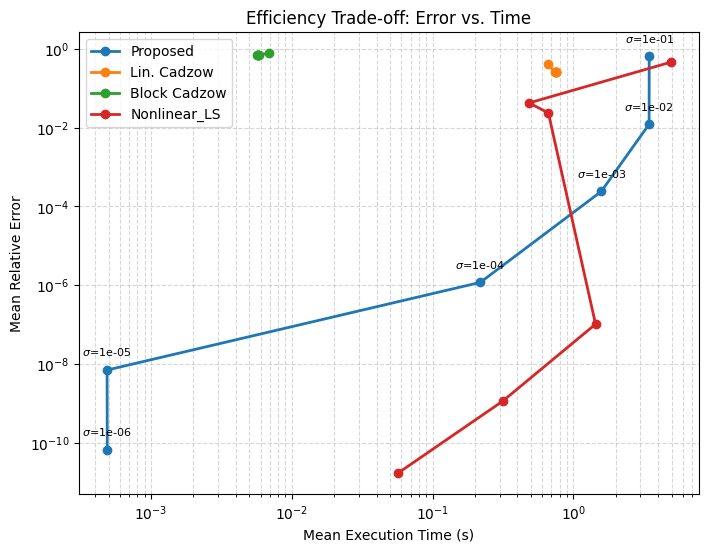

In [171]:
# Average across the 100 trials (axis=0)
# Resulting shape will be (n_noise_levels, n_methods)
avg_times = np.mean(times, axis=0)
avg_iters = np.mean(iters, axis=0) 

# Focus on a specific noise level (e.g., the 3rd index)
print(f"Method | Avg Time (s) | Avg Iterations/Nfev")
for j, name in enumerate(['Proposed', 'Lin. Cadzow', 'Block Cadzow', 'Nonlinear_LS']):
    print(f"{name:12} | {avg_times[2, j]:.4f} | {avg_iters[2, j]:.1f}")


# 1. Average across trials (axis 0)
# Results will be shape (n_noise_levels, n_methods)
avg_errs = np.mean(errs, axis=0)
avg_times = np.mean(times, axis=0)

methods = ['Proposed', 'Lin. Cadzow', 'Block Cadzow', 'Nonlinear_LS']

plt.figure(figsize=(8, 6))

for j, name in enumerate(methods):
    # Plotting Error vs Time for each method across the 6 noise levels
    plt.plot(avg_times[:, j], avg_errs[:, j], marker='o', label=name, linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mean Execution Time (s)')
plt.ylabel('Mean Relative Error')
plt.title('Efficiency Trade-off: Error vs. Time')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

# Optional: Annotate the noise levels on one of the lines
for i, txt in enumerate(noise_lev):
    plt.annotate(f"$\sigma$={txt:.0e}", (avg_times[i, 0], avg_errs[i, 0]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.show()

In [163]:
# Exp 2: influence of alpha
def run_studyalpha(y_true, u, L, r, feature_funcs, alphaval, num_trials):
    n_alpha = len(alphaval)
    print(n_alpha)
    
    # Storage
    # This matrix holds the Relative Error for every single run
    error_alpha = np.zeros((num_trials,n_alpha))
    time_alpha = np.zeros((num_trials,n_alpha))
    iters_alpha = np.zeros((num_trials,n_alpha))

    for i in range(n_alpha):
        
        for t in range(num_trials):
            y_noisy = y_true + np.random.normal(0, 1e-04, y_true.shape)
                
                
            # Execution
            t0 = time.perf_counter()
            y_denoised, iters = linearized_consensus_slra(y_noisy, u, L, r, [f1, f2], [j1, j2], alpha=alphaval[i], max_iter=10000, rho=1e-2, tol=1e-06)
            t1 = time.perf_counter() - t0
            time_alpha[t, i] = t1
            error_alpha[t, i] = rel_err(y_denoised, y_true)
            iters_alpha[t, i] = iters
                
    return error_alpha, time_alpha, iters_alpha

N=90
L = 3
gamma=1.0
ntrials = 50
alphaval = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
u_true, y_true = simulate_trajectory(N, gamma, seed=42)
r = est_rank(u_true, y_true, L, [f1, f2])
print(r)

errsal, timesal, itersal = run_studyalpha(y_true, u_true, L, r, [f1, f2], alphaval, ntrials)

#print(np.mean(errs[:,:,0],axis=0))
errP = np.mean(errsal[:,:],axis=0)



11
10


In [172]:
print(np.mean(errsal,axis=0))
print(np.std(errsal,axis=0))
print(np.mean(itersal,axis=0))

[6.78379742e-07 1.39428788e-06 1.13886842e-06 4.53448026e-06
 8.70296954e-06 2.42283157e-04 2.19705000e-05 1.12096324e-04
 1.23965068e-04 2.38017509e-04]
[1.08550814e-07 1.47515591e-06 1.66945210e-06 1.53837025e-05
 3.11632401e-05 1.06052683e-03 1.02975985e-04 7.37319179e-04
 8.25940760e-04 1.15450807e-03]
[1.00000e+00 4.91740e+02 3.72380e+02 6.17780e+02 1.01100e+03 1.34062e+03
 1.10226e+03 1.15840e+03 1.23130e+03 1.16166e+03]


In [ ]:
# Exp 2: influence of alpha with mismatch
def f3(y): 
    f = np.zeros_like(y)
    for t in range(2, len(y)):
        #f[t] = -3 * (y[t-1]**2) * y[t-2]
        f[t] = (y[t-1]**2)
    return f

def j3(y):
    N = len(y)
    L1 = np.zeros((N, N))
    for t in range(2, N):
        L1[t, t-1] =  y[t-1]
    return L1
def lifted_hankel_mis(y, u, L, feature_funcs_mis):
    blocks = []
    # Block 0: Linear y
    blocks.append(hankel(y[:L], y[L-1:]))
    # Blocks 1 to q: Nonlinear features
    for func in feature_funcs_mis:
        feat_y_mis = func(y)
        blocks.append(hankel(feat_y_mis[:L], feat_y_mis[L-1:]))
    # Block q+1: Input u
    blocks.append(hankel(u[:L], u[L-1:]))
    return np.vstack(blocks)
def run_studyalpha(y_true, u, L, r, feature_funcs, alphaval, num_trials):
    n_alpha = len(alphaval)
    print(n_alpha)
    
    # Storage
    # This matrix holds the Relative Error for every single run
    error_alpha_mis = np.zeros((num_trials,n_alpha))
    time_alpha_mis = np.zeros((num_trials,n_alpha))
    iters_alpha_mis = np.zeros((num_trials,n_alpha))

    for i in range(n_alpha):
        
        for t in range(num_trials):
            y_noisy = y_true + np.random.normal(0, 1e-04, y_true.shape)
                
                
            # Execution
            t0 = time.perf_counter()
            y_mismatch, iter_mismatch = linearized_consensus_slra(y_noisy, u, L, r, [f3, f2], [j3, j2], alpha=alphaval[i], max_iter=10000, rho=1e-2, tol=1e-06)
            t1 = time.perf_counter() - t0
            time_alpha_mis[t, i] = t1
            error_alpha_mis[t, i] = rel_err(y_mismatch, y_true)
            iters_alpha_mis[t, i] = iter_mismatch
                
    return error_alpha_mis, time_alpha_mis, iters_alpha_mis

import statistics
N=90
L = 3
gamma=1.0
ntrials = 50
alphaval = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
u_true, y_true = simulate_trajectory(N, gamma, seed=42)
r = est_rank(u_true, y_true, L, [f1, f2])
print(r)

errsalmis, timesalmis, itersalmis = run_studyalpha(y_true, u_true, L, r, [f3, f2], alphaval, ntrials)


11
10


In [167]:
import statistics
print(np.mean(itersalmis,axis=0))
print(np.mean(errsalmis, axis=0))
print(np.std(errsalmis, axis=0))

[10000. 10000. 10000. 10000. 10000. 10000. 10000. 10000. 10000. 10000.]
[0.00378674 0.00525716 0.00610309 0.00675169 0.00727433 0.00771154
 0.00807816 0.00839583 0.00867551 0.00893224]
[1.78092420e-05 1.72397129e-05 1.41906944e-05 1.06176019e-05
 1.35305557e-05 1.36403835e-05 1.25225068e-05 1.19195302e-05
 1.23527620e-05 1.13878702e-05]
